### Architecture 
In this experiment, FiLM is applied at an late stage which is last stage 8 accessible from timm, so FiLM is applied after stage 8,
Stem (Stage 1): conv_stem → bn1 → act1

MBConv stages 2–8: stored in blocks[0]..blocks[6]

blocks[0] → Stage 2 

blocks[1] → Stage 3

blocks[2] → Stage 4

blocks[3] → Stage 5

blocks[4] → Stage 6

blocks[5] → Stage 7

blocks[6] → Stage 8 ->FiLM(Late Modulation)

Head (Stage 9): conv_head → bn2 → global_pool → MLP

<br>
<br>

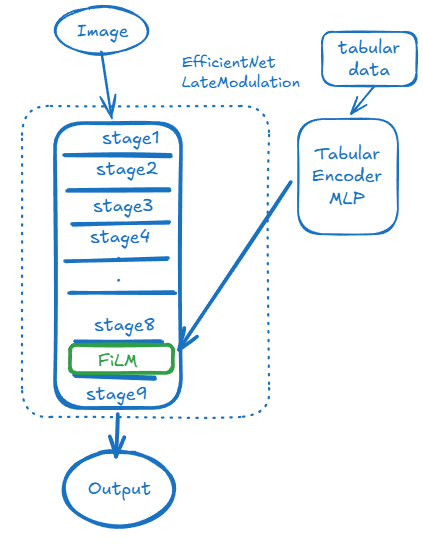



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra","exp12_film_effB1_strongAug384_BS12_identity", "exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init"

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]
cfg["img_size"] = 384
cfg["aug"] = "strong"
cfg["batch_size"] = 12

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=6,                   # to update the backbone block at late stage on index 6 (last MBCblock of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=False,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=False,              # False: to not freeze backbone, True -> Freeze backbone entirely
    identity_init=True
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=33.2088 | ValRMSE: 3467210.0000
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=20.7136 | ValRMSE: 19.7954
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=18.8050 | ValRMSE: 19.3298
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=18.3605 | ValRMSE: 19.1363
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=17.9570 | ValRMSE: 18.9803
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=17.5461 | ValRMSE: 19.1952
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=17.0600 | ValRMSE: 19.2053
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=16.6180 | ValRMSE: 19.4228
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=16.3013 | ValRMSE: 19.2022
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=16.0434 | ValRMSE: 19.6716
Early stopping at epoch 10
Fold 1 best RMSE: 18.9803

=== exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=34.1968 | ValRMSE: 25.2156
Epoch 2/10 | Fold 2 | Train[MSE]: RMS

In [5]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 18.9803 (n=1983)
Fold 2 OOF RMSE: 19.1476 (n=1983)
Fold 3 OOF RMSE: 18.5512 (n=1982)
Fold 4 OOF RMSE: 18.9824 (n=1982)
Fold 5 OOF RMSE: 19.1670 (n=1982)


### Train and Validation RMSE Curve

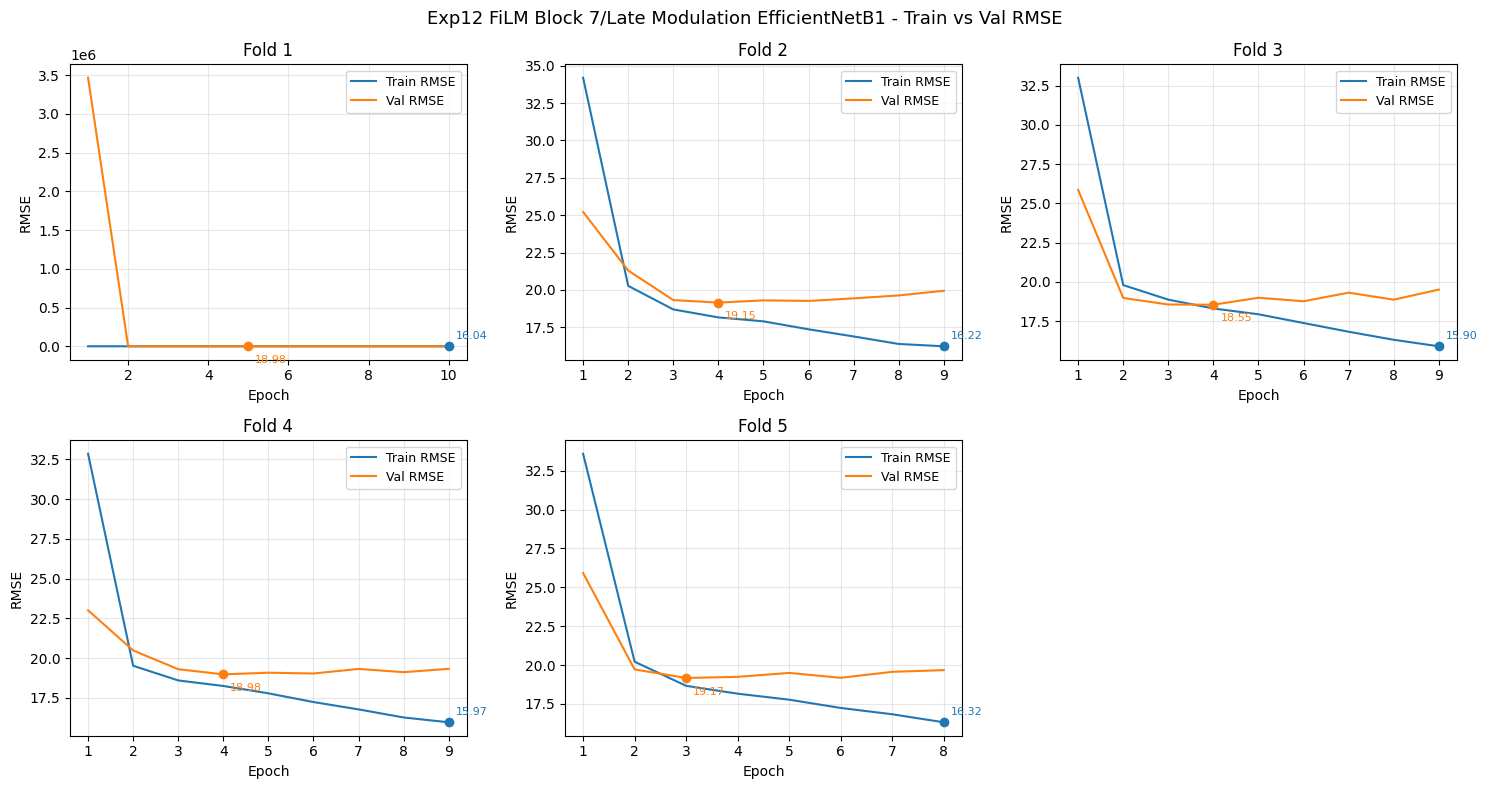

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Block 7/Late Modulation EfficientNetB1")

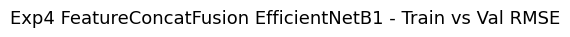

In [7]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

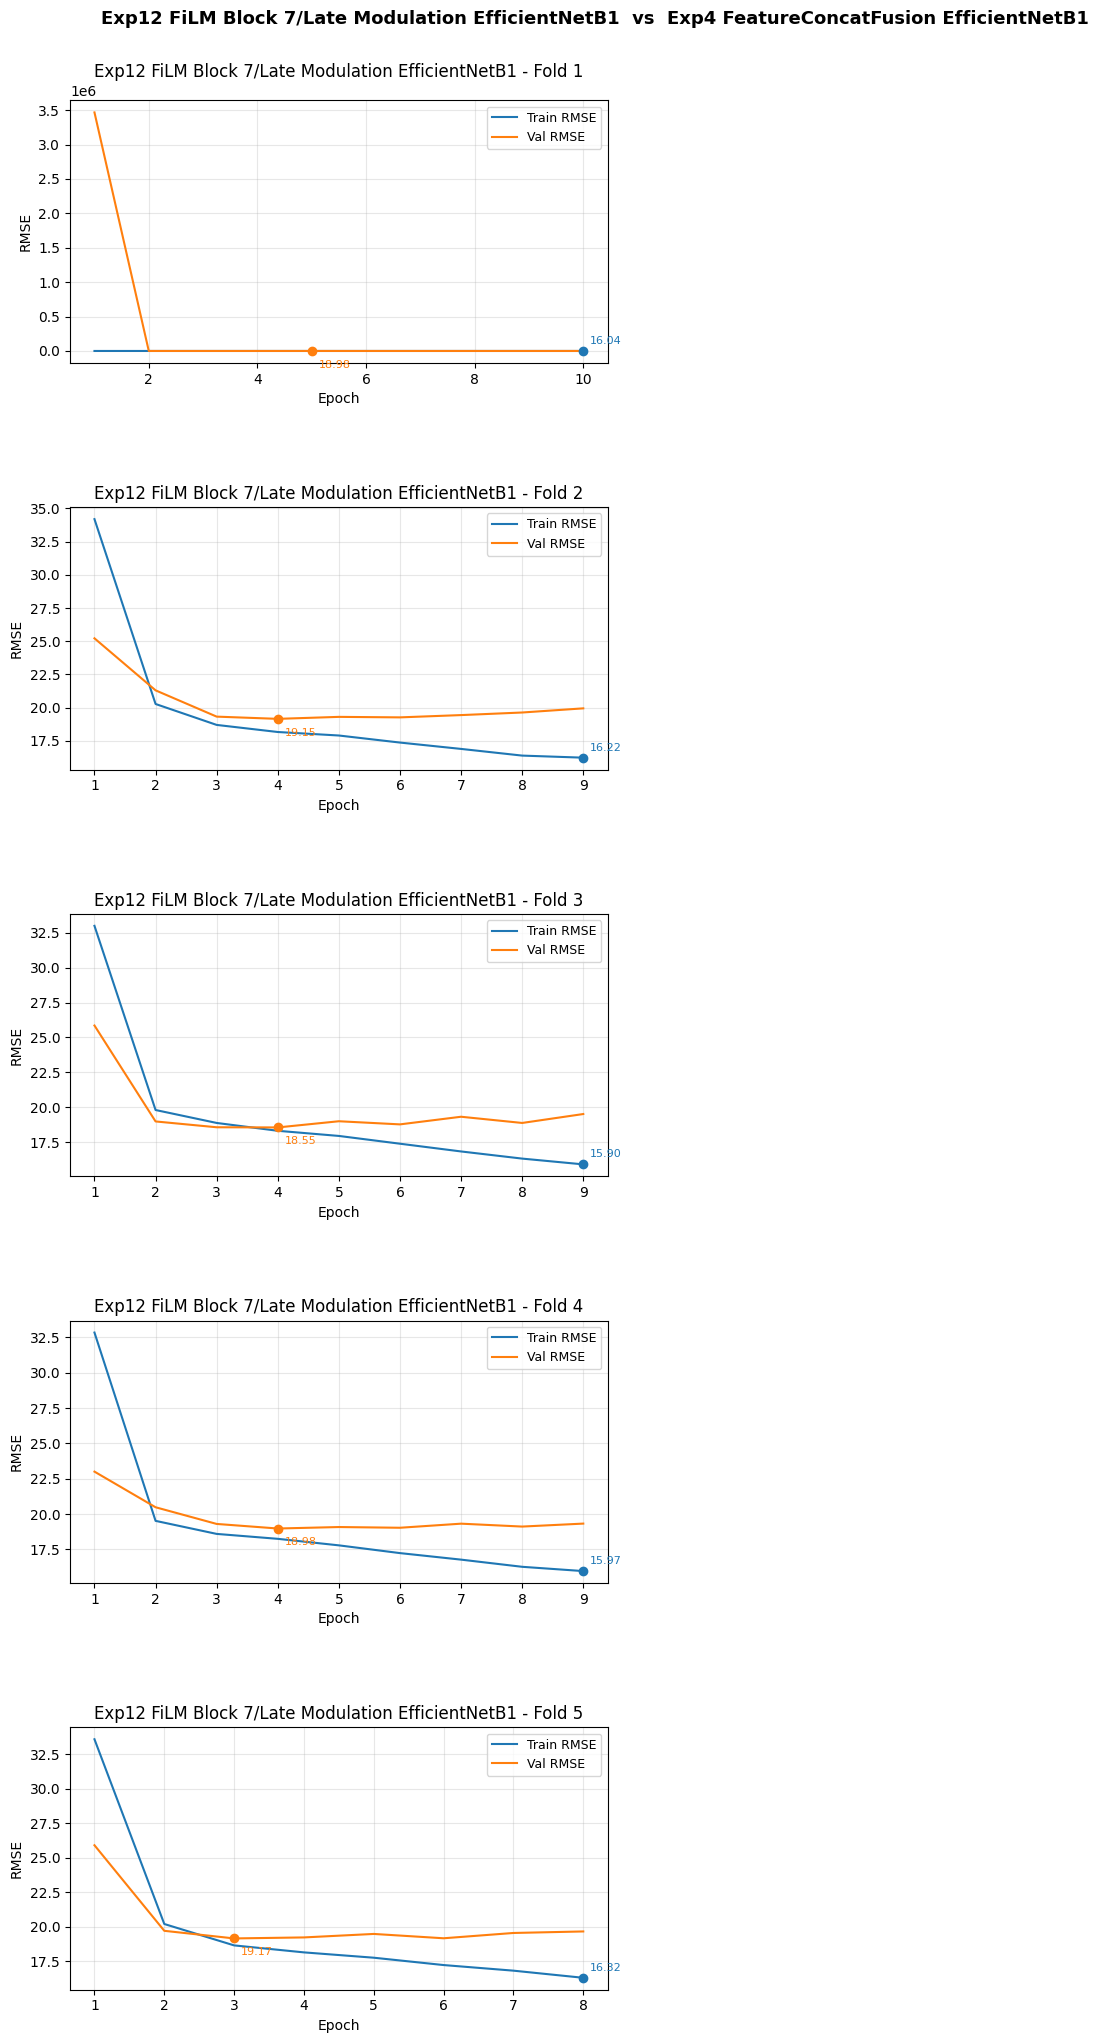

In [8]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp12 FiLM Block 7/Late Modulation EfficientNetB1", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

In [9]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,d00e5d29d4ec09de1e0e0ebec41b2d03,1,5,118.372574,113.372574
1,9fdfa0708e98d8320e0b526315bb264a,5,7,108.735527,101.735527
2,3fa409545d9c624436e83a8814ffacc6,5,100,5.651447,94.348553
3,bc39a9c4ae544bfc4118d59b9b089135,4,5,97.044022,92.044022
4,cda998949ee096e41e190f767561960a,5,12,103.936607,91.936607


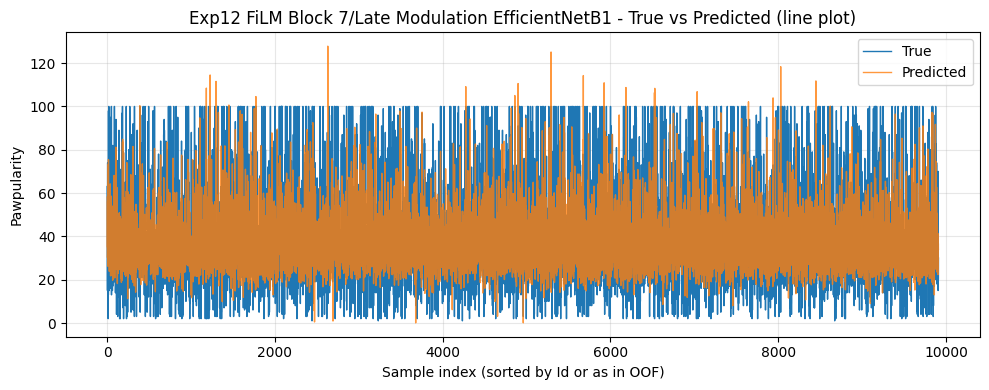

In [10]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp12 FiLM Block 7/Late Modulation EfficientNetB1")





In [11]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp12 FiLM Block 7/Late Modulation EfficientNetB1",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/exp4/oof_detail.csv'

In [ ]:
df_bins.head()

,bin,count,Exp12 FiLM Block 7/Late Modulation EfficientNetB1_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,23.262382,23.561754,0.299372,Exp12 FiLM Block 7/Late Modulation EfficientNe...
1,"(20, 40]",5119,12.103968,11.605182,-0.498787,Exp4_FeatureConcat EffB1 Fusion_better
2,"(40, 60]",2088,17.689503,16.538259,-1.151244,Exp4_FeatureConcat EffB1 Fusion_better
3,"(60, 80]",727,30.170956,30.127592,-0.043363,Exp4_FeatureConcat EffB1 Fusion_better
4,"(80, 100]",561,47.452283,46.623998,-0.828285,Exp4_FeatureConcat EffB1 Fusion_better


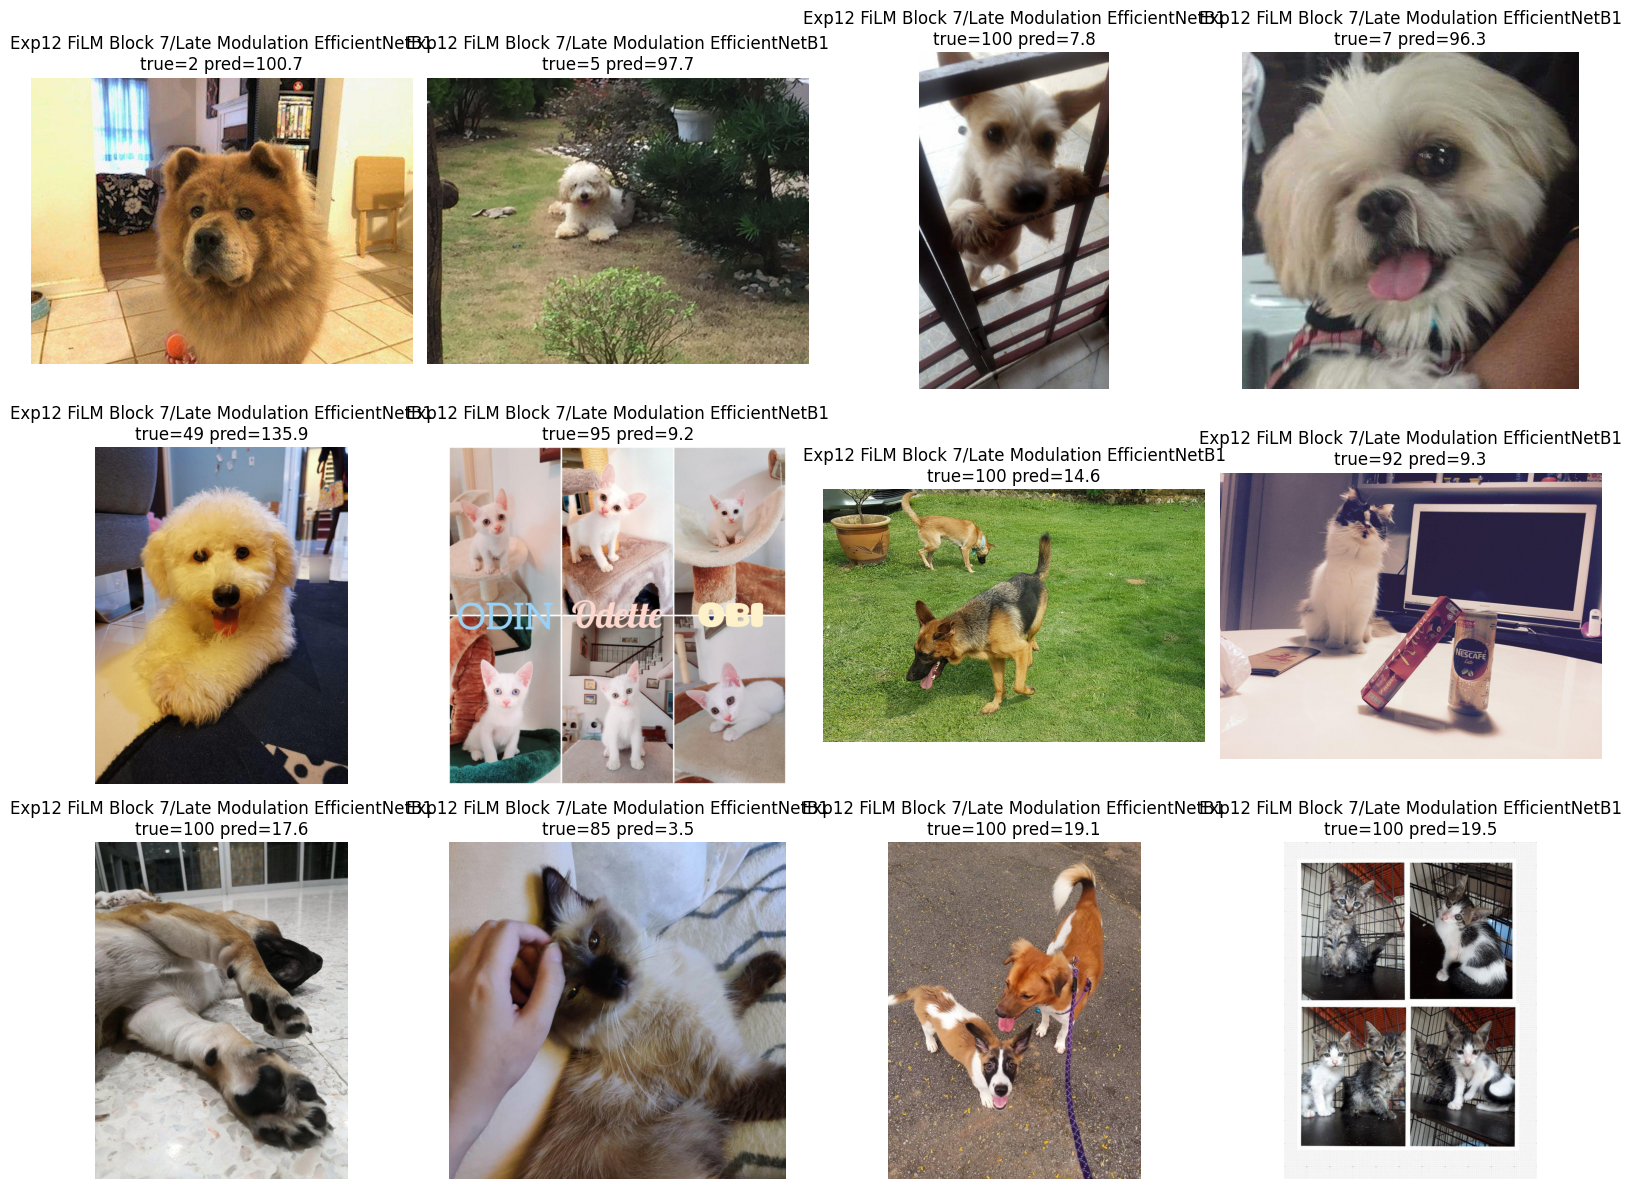

In [ ]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp12 FiLM Block 7/Late Modulation EfficientNetB1")

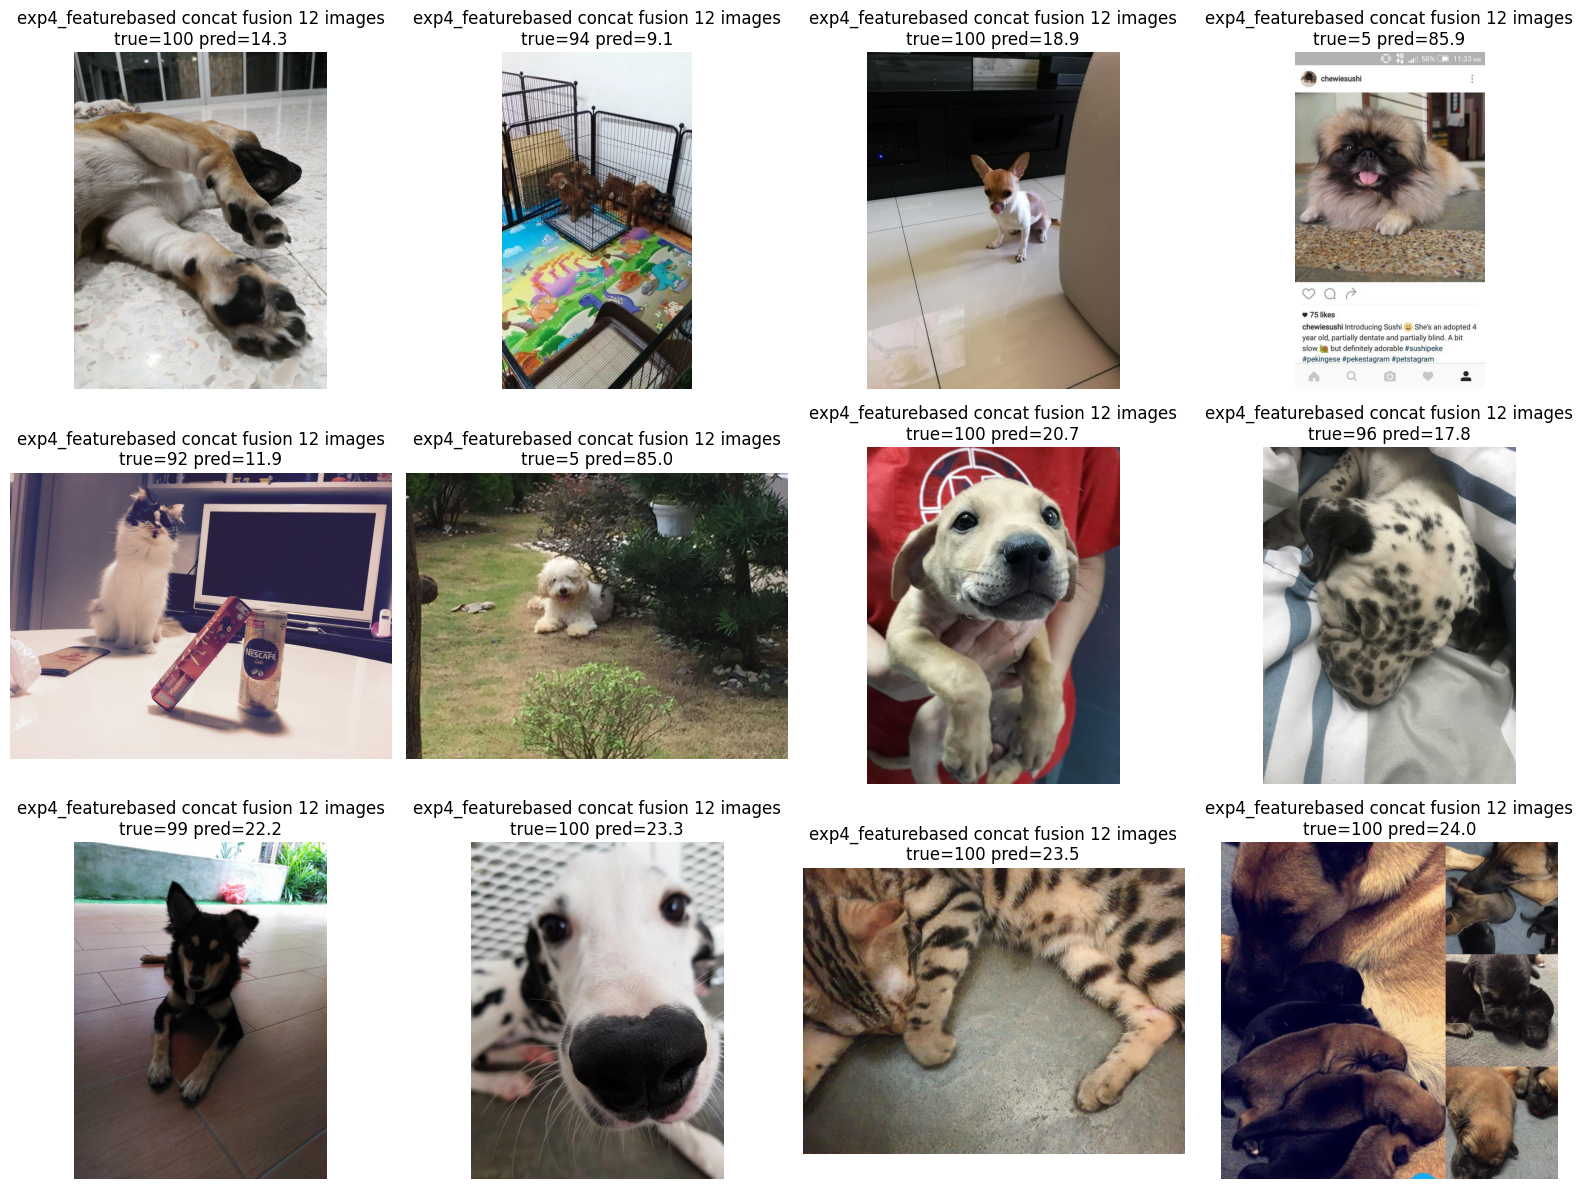

In [ ]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")